<a href="https://colab.research.google.com/github/karabeyseren-sys/CS-WinMet5-Trade-Botu/blob/main/Alt%C4%B1n_Vuru%C5%9F_Golden_Crossover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kurumsal SMC Stratejisi Yükleniyor...
----------------------------------------
🎯 KURUMSAL STRATEJİ SONUÇLARI
----------------------------------------
Toplam İşlem: 12
Başarı Oranı: %91.7
Net Kâr (1 Ons İçin): $2.00


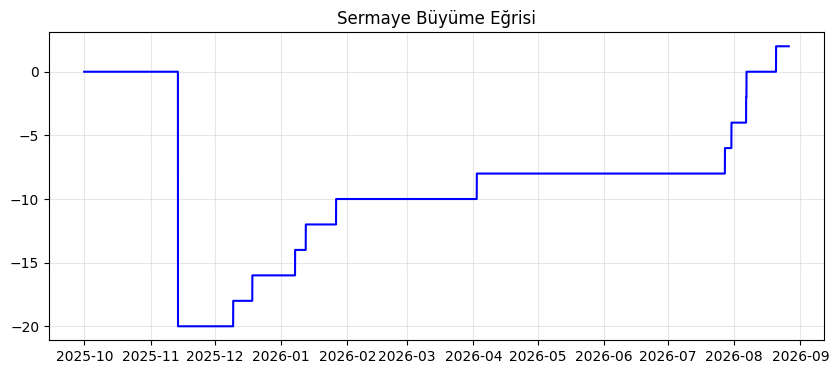

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Kurumsal SMC Stratejisi Yükleniyor...")

# 1. VERİLERİ YÜKLEME
dosya_15m = 'OANDA_XAUUSD, 15.csv'
dosya_4h = 'OANDA_XAUUSD, 240.csv' # 4 Saatlik veri

if os.path.exists(dosya_15m) and os.path.exists(dosya_4h):
    df_15m = pd.read_csv(dosya_15m).loc[:, ~pd.read_csv(dosya_15m).columns.str.contains('Unnamed')]
    df_4h = pd.read_csv(dosya_4h).loc[:, ~pd.read_csv(dosya_4h).columns.str.contains('Unnamed')]

    # Zaman indekslerini ayarlama
    df_15m['time'] = pd.to_datetime(df_15m['time'], unit='s')
    df_15m.set_index('time', inplace=True)
    df_4h['time'] = pd.to_datetime(df_4h['time'], unit='s')
    df_4h.set_index('time', inplace=True)

    # 2. STRATEJİ MODÜLLERİ

    # A. 4H Trend Filtresi (Bias)
    df_4h['EMA_20'] = df_4h['close'].ewm(span=20).mean()
    df_4h['Bias_Yukselis'] = df_4h['close'] > df_4h['EMA_20']
    df_15m['4H_Bias'] = df_4h['Bias_Yukselis'].reindex(df_15m.index, method='ffill')

    # B. FVG ve Bollinger Alt Bant Onayı
    # FVG (Yükseliş): 1. mumun tepesi ile 3. mumun dibi arasında boşluk
    df_15m['FVG_Var'] = df_15m['low'] > df_15m['high'].shift(2)
    # Bollinger Alt Banda Yakınlık (Fiyat alt banda 1 dolar veya daha yakınsa)
    df_15m['Bollinger_Yakin'] = (df_15m['close'] - df_15m['Lower']) <= 1.0

    # C. Zaman Filtresi (New York Seansı 13:00 - 17:00 UTC)
    df_15m['Saat'] = df_15m.index.hour
    df_15m['NY_Seansi'] = df_15m['Saat'].between(13, 17)

    # D. Sinyal Birleşimi (Tetikleyici)
    df_15m['Buy'] = df_15m['Buy'].fillna(0)
    df_15m['Kurumsal_Giris'] = (
        (df_15m['Buy'] > 0) &
        (df_15m['4H_Bias'] == True) &
        (df_15m['NY_Seansi'] == True) &
        (df_15m['FVG_Var'] | df_15m['Bollinger_Yakin'])
    )

    # 3. GÜVENLİ BACKTEST (SL: 20 Dolar, TP: 2 Dolar)
    TP_AMOUNT = 2.0
    SL_AMOUNT = 20.0
    toplam_kar = 0
    kasa_gecmisi = []
    open_trades = []
    closed_trades = []

    for index, row in df_15m.iterrows():
        current_high, current_low = row['high'], row['low']
        trades_to_keep = []

        for trade in open_trades:
            if trade['entry_price'] - current_low >= SL_AMOUNT:
                trade['profit'] = -SL_AMOUNT
                closed_trades.append(trade)
                toplam_kar -= SL_AMOUNT
            elif current_high >= trade['entry_price'] + TP_AMOUNT:
                trade['profit'] = TP_AMOUNT
                closed_trades.append(trade)
                toplam_kar += TP_AMOUNT
            else:
                trades_to_keep.append(trade)

        open_trades = trades_to_keep

        if row['Kurumsal_Giris']:
            open_trades.append({'entry_price': row['close']})

        kasa_gecmisi.append(toplam_kar)

    # 4. SONUÇLAR VE GRAFİK
    if closed_trades:
        kazananlar = len([t for t in closed_trades if t['profit'] > 0])
        win_rate = (kazananlar / len(closed_trades)) * 100

        print("-" * 40)
        print("🎯 KURUMSAL STRATEJİ SONUÇLARI")
        print("-" * 40)
        print(f"Toplam İşlem: {len(closed_trades)}")
        print(f"Başarı Oranı: %{win_rate:.1f}")
        print(f"Net Kâr (1 Ons İçin): ${toplam_kar:.2f}")

        plt.figure(figsize=(10, 4))
        plt.plot(df_15m.index, kasa_gecmisi, color='blue', linewidth=1.5)
        plt.title('Sermaye Büyüme Eğrisi', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("Filtrelere uygun işlem bulunamadı.")
else:
    print("Gerekli veri dosyaları bulunamadı!")